# Driven Pendulum Chaos and Poincaré Sections

Periodic and chaotic regimes, sensitivity to initial conditions, and the effects of sampling phase and frequency.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


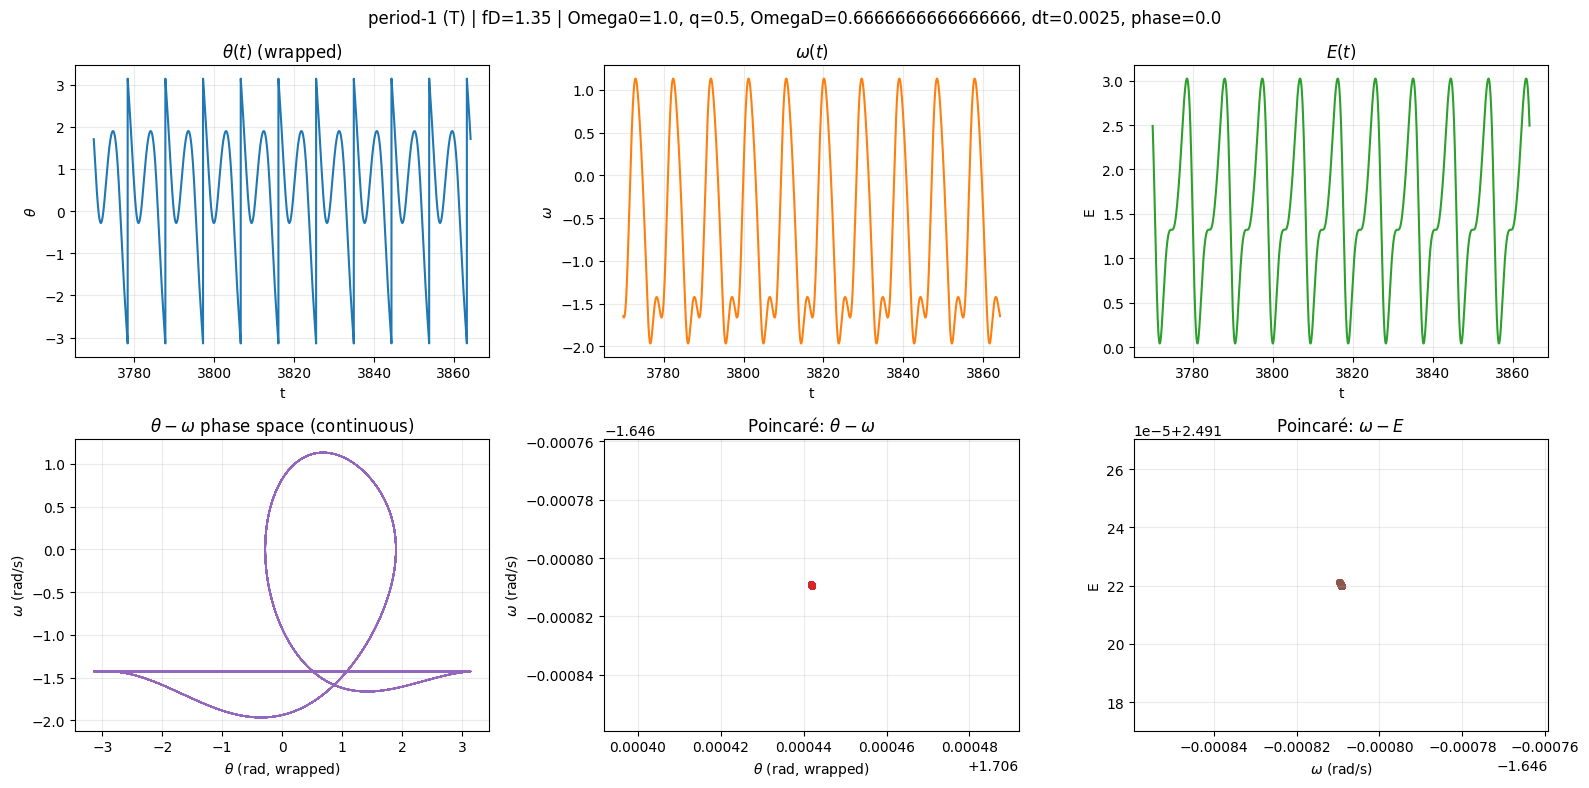

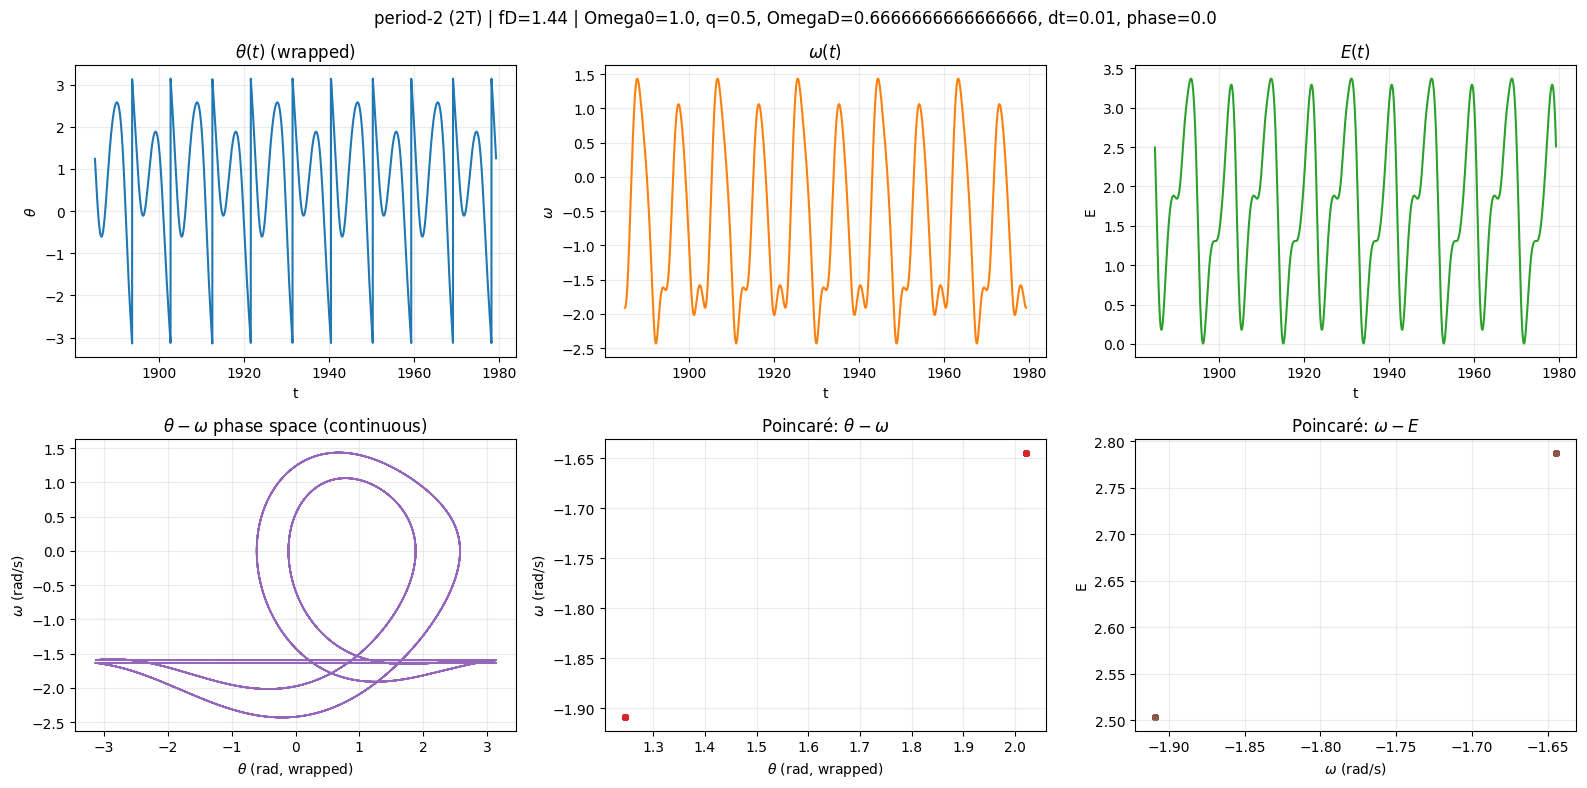

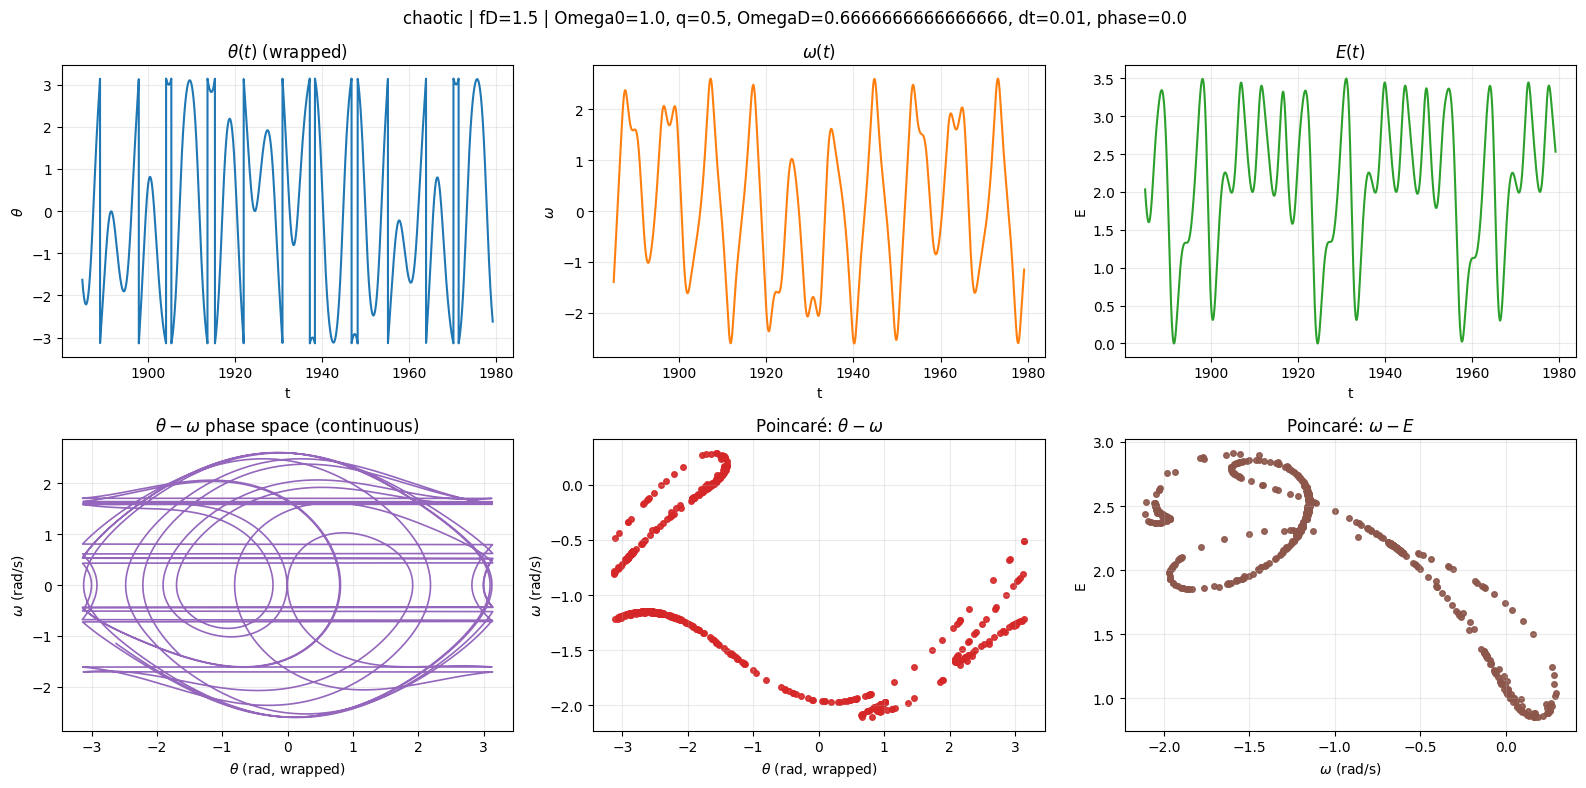

In [ ]:
# Lab 4 — Task 1

import numpy as np;
import matplotlib.pyplot as plt;

PI = np.pi;

def wrap_pm_pi(theta):
    return (theta + PI) % (2.0 * PI) - PI;

# RK2 midpoint: dtheta/dt = omega ; domega/dt = -Omega0^2 sin(theta) - q omega + fD sin(OmegaD t)
def rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax):
    nsteps = int(np.ceil(tmax / dt));
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0] = float(theta0);
    omega[0] = float(omega0);
    Omega0sq = Omega0**2;

    for i in range(nsteps):
        ti = t[i];
        th = theta[i];
        om = omega[i];
        # slope at start
        domega1 = -Omega0sq * np.sin(th) - q * om + fD * np.sin(OmegaD * ti);
        # midpoint estimate
        thh = th + 0.5 * dt * om;
        omh = om + 0.5 * dt * domega1;
        thalf = ti + 0.5 * dt;
        # slope at midpoint
        domega2 = -Omega0sq * np.sin(thh) - q * omh + fD * np.sin(OmegaD * thalf);
        # full update
        omega[i+1] = om + dt * domega2;
        theta[i+1] = th + dt * omh;

    E = 0.5 * omega**2 + Omega0sq * (1.0 - np.cos(theta));
    return t, theta, omega, E;

# Exact in-phase Poincaré sampling at OmegaD*t = 2*pi*n + phase using linear interpolation
def poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phase = 0.0):
    dt = t[1] - t[0];
    phase = phase % (2.0 * PI);
    n = np.arange(n_trans, n_trans + n_keep, dtype = int);
    tP = (2.0 * PI * n + phase) / OmegaD;

    x = tP / dt;
    i0 = np.floor(x).astype(int);
    frac = x - i0;
    i0 = np.clip(i0, 0, len(t) - 2);

    thP = theta[i0] * (1.0 - frac) + theta[i0+1] * frac;
    omP = omega[i0] * (1.0 - frac) + omega[i0+1] * frac;
    EP  = E[i0] * (1.0 - frac) + E[i0+1] * frac;

    return n, tP, wrap_pm_pi(thP), omP, EP;

# Creates ONE 2x3 figure per regime with high-contrast colors.
def plot_regime_grid(label, fD, Omega0, q, OmegaD, theta0 = 0.2, omega0 = 0.0, dt = 0.01, n_trans = 200, n_keep = 600,
                     window_drive_periods = 10, phase = 0.0, zoom_point = False):
    # High Contrast Colours
    COL_THETA = "tab:blue";
    COL_OMEGA = "tab:orange";
    COL_E     = "tab:green";
    COL_CONT  = "tab:purple";
    COL_P1    = "tab:red";
    COL_P2    = "tab:brown";

    Tdrive = 2.0 * PI / OmegaD;
    tmax = (n_trans + n_keep + 2) * Tdrive;
    # Simulate
    t, theta, omega, E = rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax);
    theta_w = wrap_pm_pi(theta);
    # Short window after transient for continuous plots
    t0 = n_trans * Tdrive;
    t1 = t0 + window_drive_periods * Tdrive;
    mask = (t >= t0) & (t <= t1);
    # Poincaré samples
    n, tP, thP, omP, EP = poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phase = phase);

    # 2x3 grid
    fig, ax = plt.subplots(2, 3, figsize = (16, 8))
    fig.suptitle(f"{label} | fD = {fD} | Omega0 = {Omega0}, q = {q}, OmegaD = {OmegaD}, dt = {dt}, phase = {phase}", fontsize = 12);

    # Top row: time series
    ax[0,0].plot(t[mask], theta_w[mask], lw = 1.5, color = COL_THETA);
    ax[0,0].set_title(r"$\theta(t)$ (wrapped)");
    ax[0,0].set_xlabel("t");
    ax[0,0].set_ylabel(r"$\theta$");
    ax[0,1].plot(t[mask], omega[mask], lw = 1.5, color = COL_OMEGA);
    ax[0,1].set_title(r"$\omega(t)$");
    ax[0,1].set_xlabel("t");
    ax[0,1].set_ylabel(r"$\omega$");
    ax[0,2].plot(t[mask], E[mask], lw = 1.5, color = COL_E);
    ax[0,2].set_title(r"$E(t)$");
    ax[0,2].set_xlabel("t");
    ax[0,2].set_ylabel("E");

    # Bottom row: phase space + Poincaré sections
    ax[1,0].plot(theta_w[mask], omega[mask], lw = 1.2, color = COL_CONT);
    ax[1,0].set_title(r"$\theta-\omega$ phase space (continuous)");
    ax[1,0].set_xlabel(r"$\theta$ (rad, wrapped)");
    ax[1,0].set_ylabel(r"$\omega$ (rad/s)");
    ax[1,1].scatter(thP, omP, s = 16, color = COL_P1, alpha = 0.9);
    ax[1,1].set_title(r"Poincaré: $\theta-\omega$");
    ax[1,1].set_xlabel(r"$\theta$ (rad, wrapped)");
    ax[1,1].set_ylabel(r"$\omega$ (rad/s)");
    ax[1,2].scatter(omP, EP, s = 16, color = COL_P2, alpha = 0.9);
    ax[1,2].set_title(r"Poincaré: $\omega-E$");
    ax[1,2].set_xlabel(r"$\omega$ (rad/s)");
    ax[1,2].set_ylabel("E");

    # Optional zoom so period-1 looks like a point (no "line")
    if zoom_point:
        th0, om0, E0 = np.mean(thP), np.mean(omP), np.mean(EP);
        dth = max(5e-5, 5*np.std(thP));
        dom = max(5e-5, 5*np.std(omP));
        dE  = max(5e-5, 5*np.std(EP));

        ax[1,1].set_xlim(th0 - dth, th0 + dth);
        ax[1,1].set_ylim(om0 - dom, om0 + dom);
        ax[1,2].set_xlim(om0 - dom, om0 + dom);
        ax[1,2].set_ylim(E0 - dE,  E0 + dE);

    # Improving readability
    for a in ax.ravel():
        a.grid(True, alpha = 0.25);

    plt.tight_layout();
    plt.show();

def main():
    # Defining parameters and initial conditions
    Omega0 = 1.0;
    q = 0.5;
    OmegaD = 2.0/3.0;
    phase = 0.0;
    theta0 = 0.2;
    omega0 = 0.0;
    window_drive_periods = 10;
    n_keep = 600;

    # Period-1: smaller dt + longer transient + zoom for "single point" look
    plot_regime_grid(label="period-1 (T)", fD = 1.35, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = 0.0025,
                     n_trans = 400, n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = True);

    # Period-2: regular dt = 0.01
    plot_regime_grid(label = "period-2 (2T)", fD = 1.44, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = 0.01,
                     n_trans = 200, n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = False);

    # Chaotic: regular dt = 0.01
    plot_regime_grid(label = "chaotic", fD = 1.50, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = 0.01,
                     n_trans = 200, n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = False);

if __name__ == "__main__":
    main();


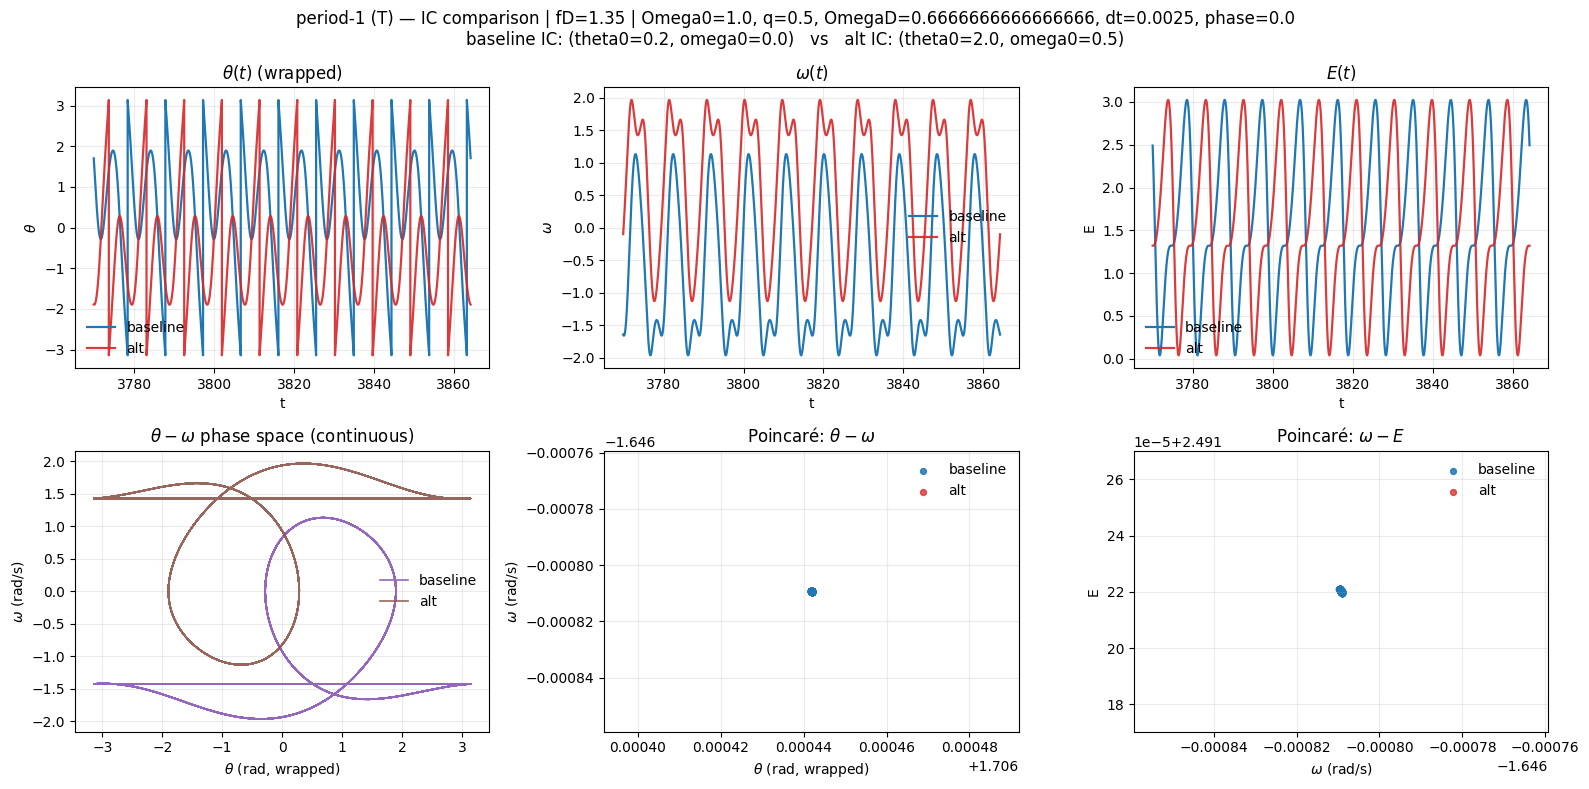

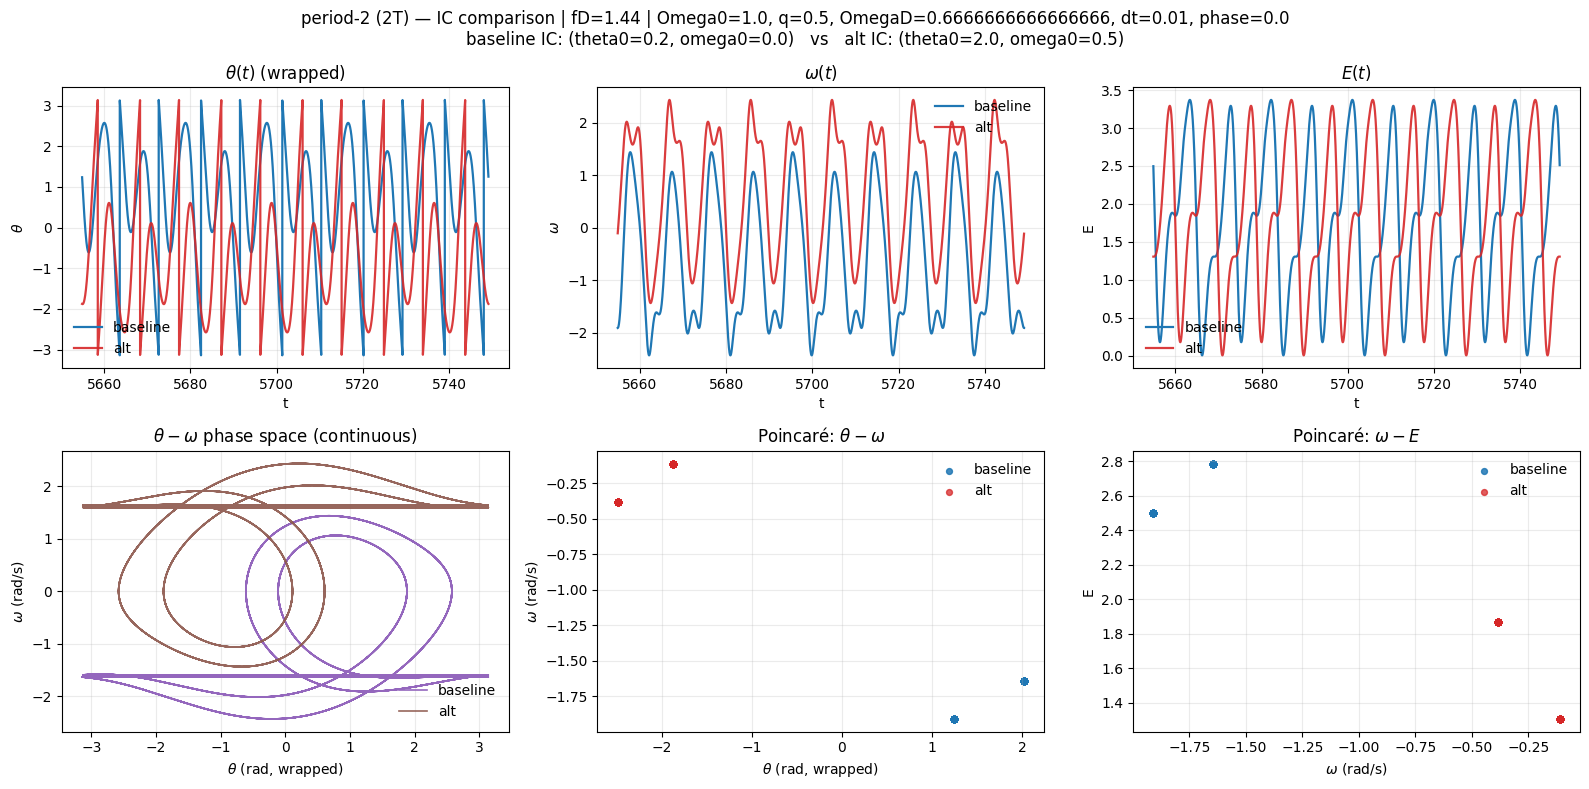

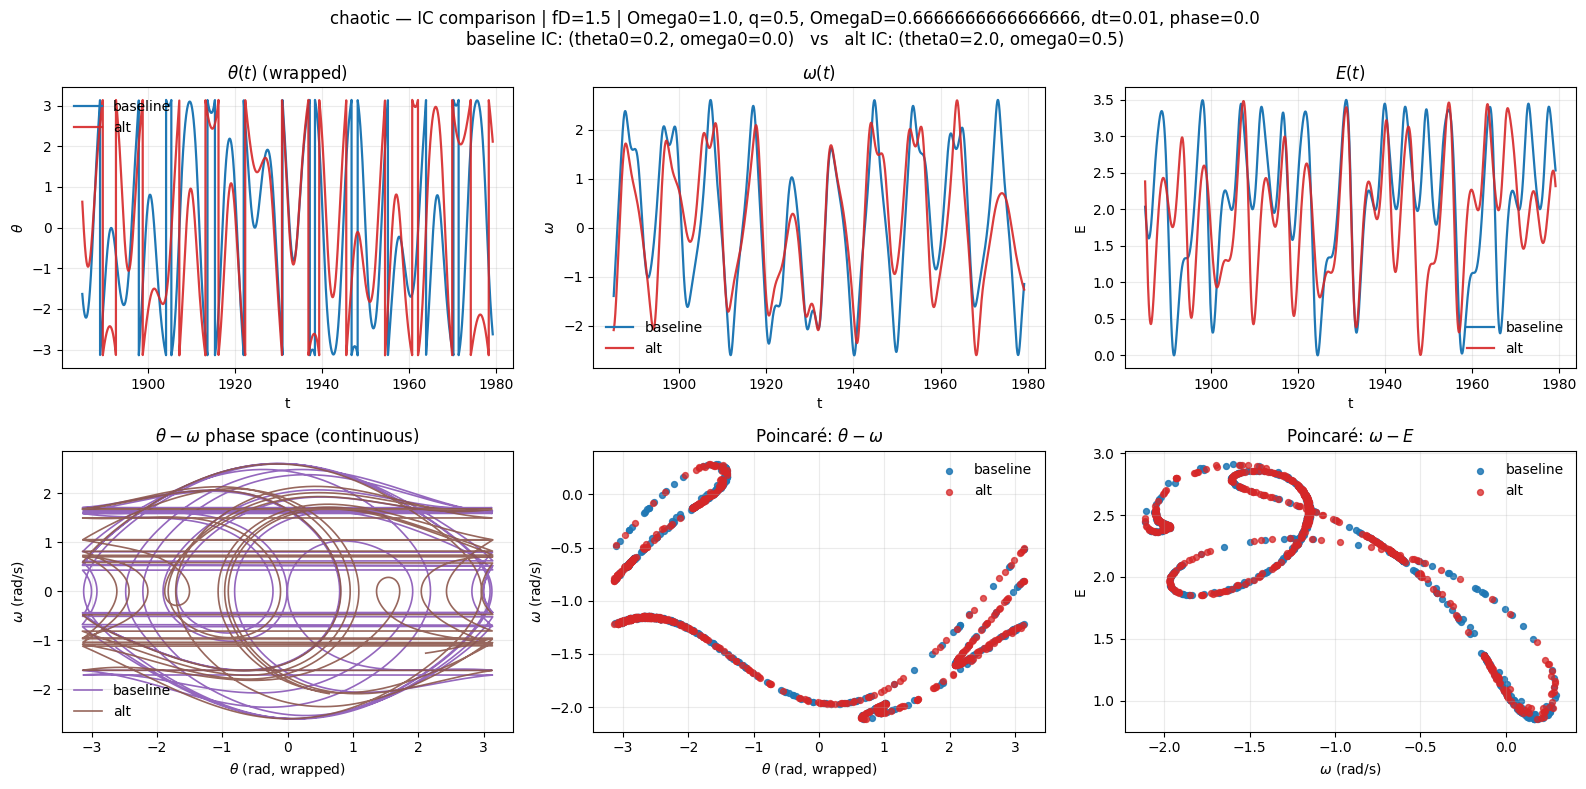

In [ ]:
# Lab 4 — Task 2

import numpy as np;
import matplotlib.pyplot as plt;

PI = np.pi;

def wrap_pm_pi(theta):
    return (theta + PI) % (2.0 * PI) - PI;

# RK2 midpoint: dtheta/dt = omega ; domega/dt = -Omega0^2 sin(theta) - q omega + fD sin(OmegaD t)
def rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax):
    nsteps = int(np.ceil(tmax / dt));
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0] = float(theta0);
    omega[0] = float(omega0);
    Omega0sq = Omega0**2;

    for i in range(nsteps):
        ti = t[i];
        th = theta[i];
        om = omega[i];
        # slope at start
        domega1 = -Omega0sq * np.sin(th) - q * om + fD * np.sin(OmegaD * ti);
        # midpoint estimate
        th_mid = th + 0.5 * dt * om;
        om_mid = om + 0.5 * dt * domega1;
        t_mid = ti + 0.5 * dt;
        # slope at midpoint
        domega2 = -Omega0sq * np.sin(th_mid) - q * om_mid + fD * np.sin(OmegaD * t_mid);
        # full update
        omega[i + 1] = om + dt * domega2;
        theta[i + 1] = th + dt * om_mid;

    E = 0.5 * omega**2 + Omega0sq * (1.0 - np.cos(theta));
    return t, theta, omega, E;

# Exact in-phase Poincaré sampling at OmegaD*t = 2*pi*n + phase using linear interpolation
def poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phase = 0.0):
    dt = t[1] - t[0];
    phase = (phase % (2.0 * PI));
    n = np.arange(n_trans, n_trans + n_keep, dtype = int);
    tP = (2.0 * PI * n + phase) / OmegaD;

    x = tP / dt;
    i0 = np.floor(x).astype(int);
    frac = x - i0;
    i0 = np.clip(i0, 0, len(t) - 2);

    thP = theta[i0] * (1.0 - frac) + theta[i0 + 1] * frac;
    omP = omega[i0] * (1.0 - frac) + omega[i0 + 1] * frac;
    EP  = E[i0] * (1.0 - frac) + E[i0 + 1] * frac;

    return n, tP, wrap_pm_pi(thP), omP, EP;

def simulate_for_task(theta0, omega0, Omega0, q, fD, OmegaD, dt, n_trans, n_keep, window_drive_periods, phase):
    Tdrive = 2.0 * PI / OmegaD;
    tmax = (n_trans + n_keep + 2) * Tdrive;
    t, theta, omega, E = rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax);
    theta_w = wrap_pm_pi(theta);
    # Window after transient for continuous plots
    t0 = n_trans * Tdrive;
    t1 = t0 + window_drive_periods * Tdrive;
    mask = (t >= t0) & (t <= t1);
    # Poincaré samples
    n, tP, thP, omP, EP = poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phase = phase);

    return {"t": t, "theta_w": theta_w, "omega": omega, "E": E, "mask": mask, "thP": thP, "omP": omP, "EP": EP};

def plot_ic_comparison_grid(label, fD, Omega0, q, OmegaD, theta0_base, omega0_base, theta0_alt,  omega0_alt, dt, n_trans, n_keep,
                            window_drive_periods, phase = 0.0, zoom_point = False):
    # High-contrast colors for overlays (no yellow)
    C_BASE = "tab:blue";
    C_ALT  = "tab:red";
    C_BASE2 = "tab:purple";
    C_ALT2  = "tab:brown";

    base = simulate_for_task(theta0_base, omega0_base, Omega0, q, fD, OmegaD, dt, n_trans, n_keep, window_drive_periods, phase);
    alt  = simulate_for_task(theta0_alt,  omega0_alt,  Omega0, q, fD, OmegaD, dt, n_trans, n_keep, window_drive_periods, phase);

    fig, ax = plt.subplots(2, 3, figsize = (16, 8));
    fig.suptitle(f"{label} | fD = {fD} | Omega0 = {Omega0}, q = {q}, OmegaD = {OmegaD}, dt = {dt}, phase = {phase}\n"
                 f"baseline IC: (theta0 = {theta0_base}, omega0 = {omega0_base})   vs   alt IC: (theta0 = {theta0_alt}, omega0 = {omega0_alt})",
                 fontsize = 12);

    # Top row: time series overlays
    # theta(t)
    ax[0,0].plot(base["t"][base["mask"]], base["theta_w"][base["mask"]], lw = 1.6, color = C_BASE, label = "baseline");
    ax[0,0].plot(alt["t"][alt["mask"]],   alt["theta_w"][alt["mask"]], lw = 1.6, color = C_ALT,  alpha = 0.9, label = "alt");
    ax[0,0].set_title(r"$\theta(t)$ (wrapped)");
    ax[0,0].set_xlabel("t");
    ax[0,0].set_ylabel(r"$\theta$");
    ax[0,0].legend(frameon = False);
    # omega(t)
    ax[0,1].plot(base["t"][base["mask"]], base["omega"][base["mask"]], lw = 1.6, color = C_BASE, label = "baseline");
    ax[0,1].plot(alt["t"][alt["mask"]],   alt["omega"][alt["mask"]], lw = 1.6, color = C_ALT,  alpha = 0.9, label = "alt");
    ax[0,1].set_title(r"$\omega(t)$");
    ax[0,1].set_xlabel("t");
    ax[0,1].set_ylabel(r"$\omega$");
    ax[0,1].legend(frameon = False);
    # E(t)
    ax[0,2].plot(base["t"][base["mask"]], base["E"][base["mask"]], lw = 1.6, color = C_BASE, label = "baseline");
    ax[0,2].plot(alt["t"][alt["mask"]],   alt["E"][alt["mask"]], lw = 1.6, color = C_ALT,  alpha = 0.9, label = "alt");
    ax[0,2].set_title(r"$E(t)$");
    ax[0,2].set_xlabel("t");
    ax[0,2].set_ylabel("E");
    ax[0,2].legend(frameon = False);

    # Bottom row: continuous phase + Poincaré overlays
    # continuous theta-omega
    ax[1,0].plot(base["theta_w"][base["mask"]], base["omega"][base["mask"]], lw = 1.2, color = C_BASE2, label = "baseline");
    ax[1,0].plot(alt["theta_w"][alt["mask"]],   alt["omega"][alt["mask"]], lw = 1.2, color = C_ALT2,  alpha = 0.9, label = "alt");
    ax[1,0].set_title(r"$\theta-\omega$ phase space (continuous)");
    ax[1,0].set_xlabel(r"$\theta$ (rad, wrapped)");
    ax[1,0].set_ylabel(r"$\omega$ (rad/s)");
    ax[1,0].legend(frameon = False);
    # Poincaré theta-omega
    ax[1,1].scatter(base["thP"], base["omP"], s = 18, color = C_BASE, alpha = 0.85, label = "baseline");
    ax[1,1].scatter(alt["thP"],  alt["omP"], s = 18, color = C_ALT,  alpha = 0.75, label = "alt");
    ax[1,1].set_title(r"Poincaré: $\theta-\omega$");
    ax[1,1].set_xlabel(r"$\theta$ (rad, wrapped)");
    ax[1,1].set_ylabel(r"$\omega$ (rad/s)");
    ax[1,1].legend(frameon = False);
    # Poincaré omega-E
    ax[1,2].scatter(base["omP"], base["EP"], s = 18, color = C_BASE, alpha = 0.85, label = "baseline");
    ax[1,2].scatter(alt["omP"],  alt["EP"], s = 18, color = C_ALT,  alpha = 0.75, label = "alt");
    ax[1,2].set_title(r"Poincaré: $\omega-E$");
    ax[1,2].set_xlabel(r"$\omega$ (rad/s)");
    ax[1,2].set_ylabel("E");
    ax[1,2].legend(frameon = False);

    # For period-1 to see point on point
    if zoom_point:
        # Use baseline statistics for the zoom center/scale
        th0, om0, E0 = np.mean(base["thP"]), np.mean(base["omP"]), np.mean(base["EP"]);
        dth = max(5e-5, 6*np.std(base["thP"]));
        dom = max(5e-5, 6*np.std(base["omP"]));
        dE  = max(5e-5, 6*np.std(base["EP"]));

        ax[1,1].set_xlim(th0 - dth, th0 + dth);
        ax[1,1].set_ylim(om0 - dom, om0 + dom);
        ax[1,2].set_xlim(om0 - dom, om0 + dom);
        ax[1,2].set_ylim(E0 - dE,  E0 + dE);

    for a in ax.ravel():
        a.grid(True, alpha = 0.25);

    plt.tight_layout();
    plt.show();

def main():
    Omega0 = 1.0;
    q = 0.5;
    OmegaD = 2.0/3.0;
    phase = 0.0;
    # Baseline initial conditions = Task 1
    theta0_base = 0.2;
    omega0_base = 0.0;
    window_drive_periods = 10;
    n_keep = 600;
    # Alternate initial conditions
    theta0_alt = 2.0;
    omega0_alt = 0.5;

    # Period-1: smaller dt + longer transient + zoom
    plot_ic_comparison_grid(label = "period-1 (T) — IC comparison", fD = 1.35, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0_base = theta0_base,
                            omega0_base = omega0_base, theta0_alt = theta0_alt,  omega0_alt = omega0_alt, dt = 0.0025, n_trans = 400,
                            n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = True);
    # Period-2
    plot_ic_comparison_grid(label = "period-2 (2T) — IC comparison", fD = 1.44, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0_base = theta0_base,
                            omega0_base = omega0_base, theta0_alt = theta0_alt,  omega0_alt = omega0_alt, dt = 0.01, n_trans = 600,
                            n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = False);

    # Chaotic
    plot_ic_comparison_grid(label = "chaotic — IC comparison", fD = 1.50, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0_base = theta0_base,
                            omega0_base = omega0_base, theta0_alt = theta0_alt,  omega0_alt = omega0_alt, dt = 0.01, n_trans = 200,
                            n_keep = n_keep, window_drive_periods = window_drive_periods, phase = phase, zoom_point = False);


if __name__ == "__main__":
    main();




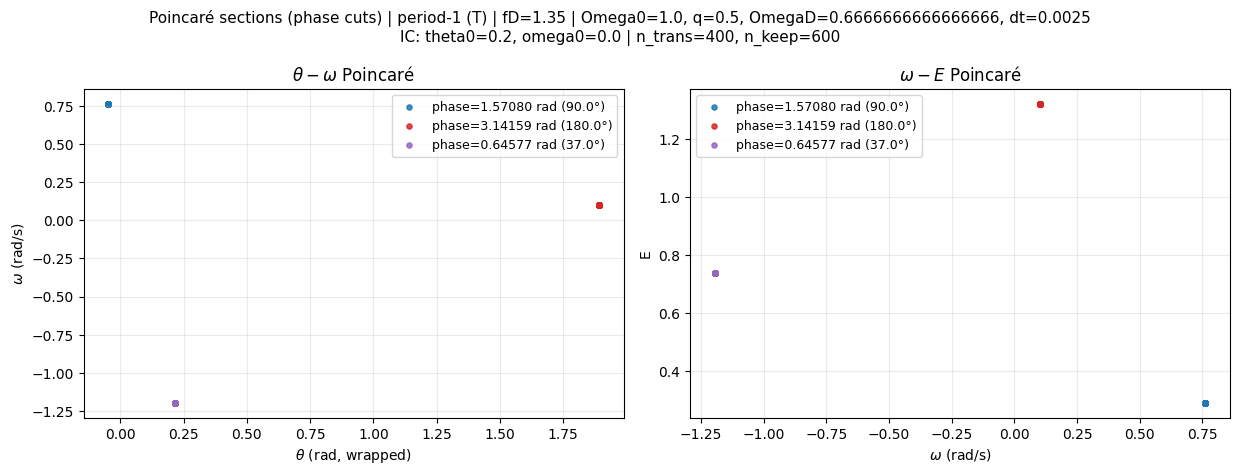

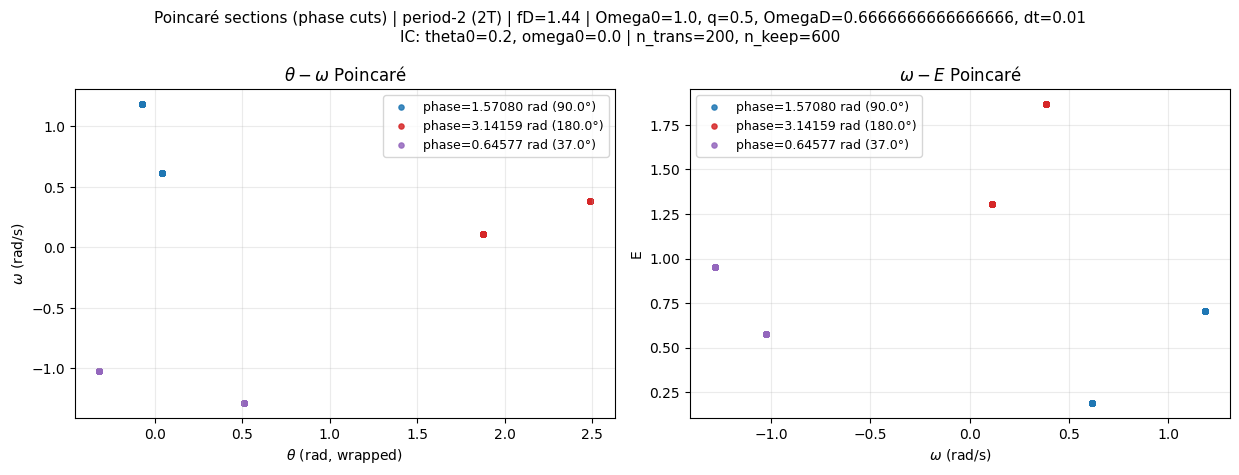

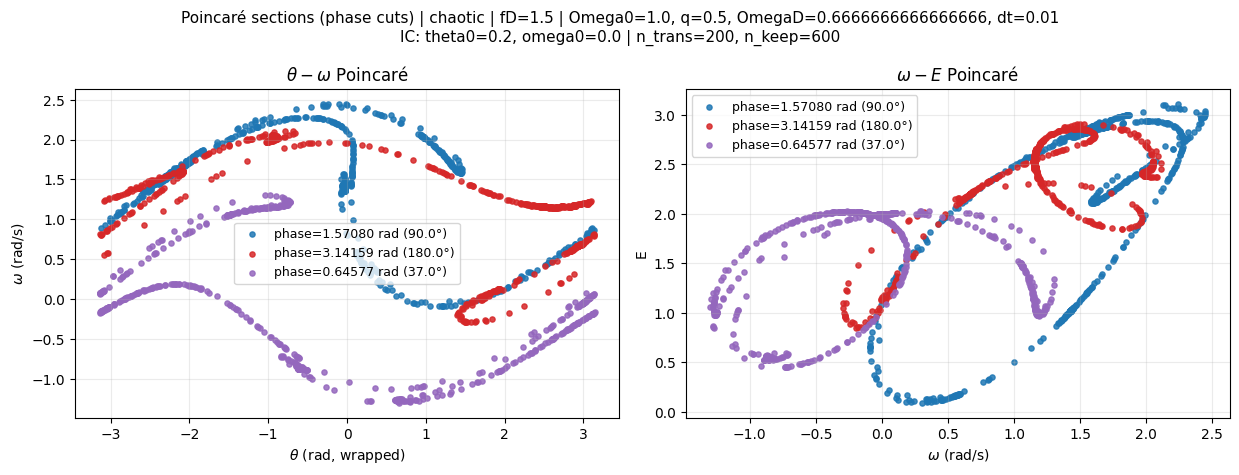

In [ ]:
# Lab 4 — Task 3

import numpy as np;
import matplotlib.pyplot as plt;

PI = np.pi;

def wrap_pm_pi(theta):
    return (theta + PI) % (2.0 * PI) - PI;

# RK2 midpoint: dtheta/dt = omega ; domega/dt = -Omega0^2 sin(theta) - q omega + fD sin(OmegaD t)
def rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax):
    nsteps = int(np.ceil(tmax / dt));
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0] = float(theta0);
    omega[0] = float(omega0);
    Omega0sq = Omega0 ** 2;

    for i in range(nsteps):
        ti = t[i];
        th = theta[i];
        om = omega[i];
        # slope at start
        domega1 = -Omega0sq * np.sin(th) - q * om + fD * np.sin(OmegaD * ti);
        # midpoint estimate
        thh = th + 0.5 * dt * om;
        omh = om + 0.5 * dt * domega1;
        thalf = ti + 0.5 * dt;
        # slope at midpoint
        domega2 = -Omega0sq * np.sin(thh) - q * omh + fD * np.sin(OmegaD * thalf);
        # full update
        omega[i + 1] = om + dt * domega2;
        theta[i + 1] = th + dt * omh;

    E = 0.5 * omega**2 + Omega0sq * (1.0 - np.cos(theta));
    return t, theta, omega, E;

# Exact Poincaré sampling at OmegaD*t = 2*pi*n + phase using linear interpolation
def poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phase = 0.0):
    dt = t[1] - t[0];
    phase = phase % (2.0 * PI);
    n = np.arange(n_trans, n_trans + n_keep, dtype = int);
    tP = (2.0 * PI * n + phase) / OmegaD;

    x = tP / dt;
    i0 = np.floor(x).astype(int);
    frac = x - i0;
    i0 = np.clip(i0, 0, len(t) - 2);

    thP = theta[i0] * (1.0 - frac) + theta[i0 + 1] * frac;
    omP = omega[i0] * (1.0 - frac) + omega[i0 + 1] * frac;
    EP  = E[i0]     * (1.0 - frac) + E[i0 + 1] * frac;

    return n, tP, wrap_pm_pi(thP), omP, EP;

def simulate_for_poincare(Omega0, q, OmegaD, fD, theta0, omega0, dt, n_trans, n_keep):
    Tdrive = 2.0 * PI / OmegaD;
    tmax = (n_trans + n_keep + 2) * Tdrive;
    t, theta, omega, E = rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax);
    return t, theta, omega, E;

def plot_poincare_phasecuts(label, fD, Omega0, q, OmegaD, theta0 = 0.2, omega0 = 0.0, dt = 0.01, n_trans = 200, n_keep = 600,
                            phases = (PI/2, PI, 37.0*PI/180.0), pointsize = 14):
    # High-contrast colors for the three phase cuts (avoid yellow)
    PHASE_COLORS = ["tab:blue", "tab:red", "tab:purple"]
    # Sim once (reuse trajectory), then sample at 3 phases
    t, theta, omega, E = simulate_for_poincare(Omega0, q, OmegaD, fD, theta0, omega0, dt, n_trans, n_keep);

    fig, ax = plt.subplots(1, 2, figsize = (12.5, 4.8));
    fig.suptitle(f"Poincaré sections (phase cuts) | {label} | fD = {fD} | Omega0 = {Omega0}, q = {q}, OmegaD = {OmegaD}, dt = {dt}\n"
        f"IC: theta0 = {theta0}, omega0 = {omega0} | n_trans = {n_trans}, n_keep = {n_keep}", fontsize = 11);
    # θ-ω and ω-E panels
    ax[0].set_title(r"$\theta-\omega$ Poincaré");
    ax[0].set_xlabel(r"$\theta$ (rad, wrapped)");
    ax[0].set_ylabel(r"$\omega$ (rad/s)");
    ax[1].set_title(r"$\omega-E$ Poincaré");
    ax[1].set_xlabel(r"$\omega$ (rad/s)");
    ax[1].set_ylabel("E");

    for ph, col in zip(phases, PHASE_COLORS):
        _, _, thP, omP, EP = poincare_samples_interpolated(t, theta, omega, E, OmegaD, n_trans, n_keep, phas = ph);
        ph_deg = (ph * 180.0 / PI) % 360.0;
        lab = f"phase = {ph:.5f} rad ({ph_deg:.1f}°)";
        ax[0].scatter(thP, omP, s = pointsize, color = col, alpha = 0.85, label = lab);
        ax[1].scatter(omP, EP, s = pointsize, color = col, alpha = 0.85, label = lab);

    for a in ax:
        a.grid(True, alpha = 0.25);
        a.legend(frameon = True, fontsize = 9);

    plt.tight_layout();
    plt.show();

def main():
    # Baseline parameters
    Omega0 = 1.0;
    q = 0.5;
    OmegaD = 2.0/3.0;
    theta0 = 0.2;
    omega0 = 0.0;
    n_keep = 600;
    phases = (PI/2, PI, (37.0 * PI/180.0)); # Phase cuts

    # Period-1: smaller dt + longer transient
    plot_poincare_phasecuts(label = "period-1 (T)", fD = 1.35, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0,
                            dt = 0.0025, n_trans = 400, n_keep = n_keep, phases = phases);
    # Period-2
    plot_poincare_phasecuts(label = "period-2 (2T)", fD = 1.44, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0,
                            dt = 0.01, n_trans = 200, n_keep = n_keep, phases = phases);
    # chaotic
    plot_poincare_phasecuts(label = "chaotic", fD = 1.50, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0,
                            dt = 0.01, n_trans = 200, n_keep = n_keep, phases = phases);

if __name__ == "__main__":
    main();


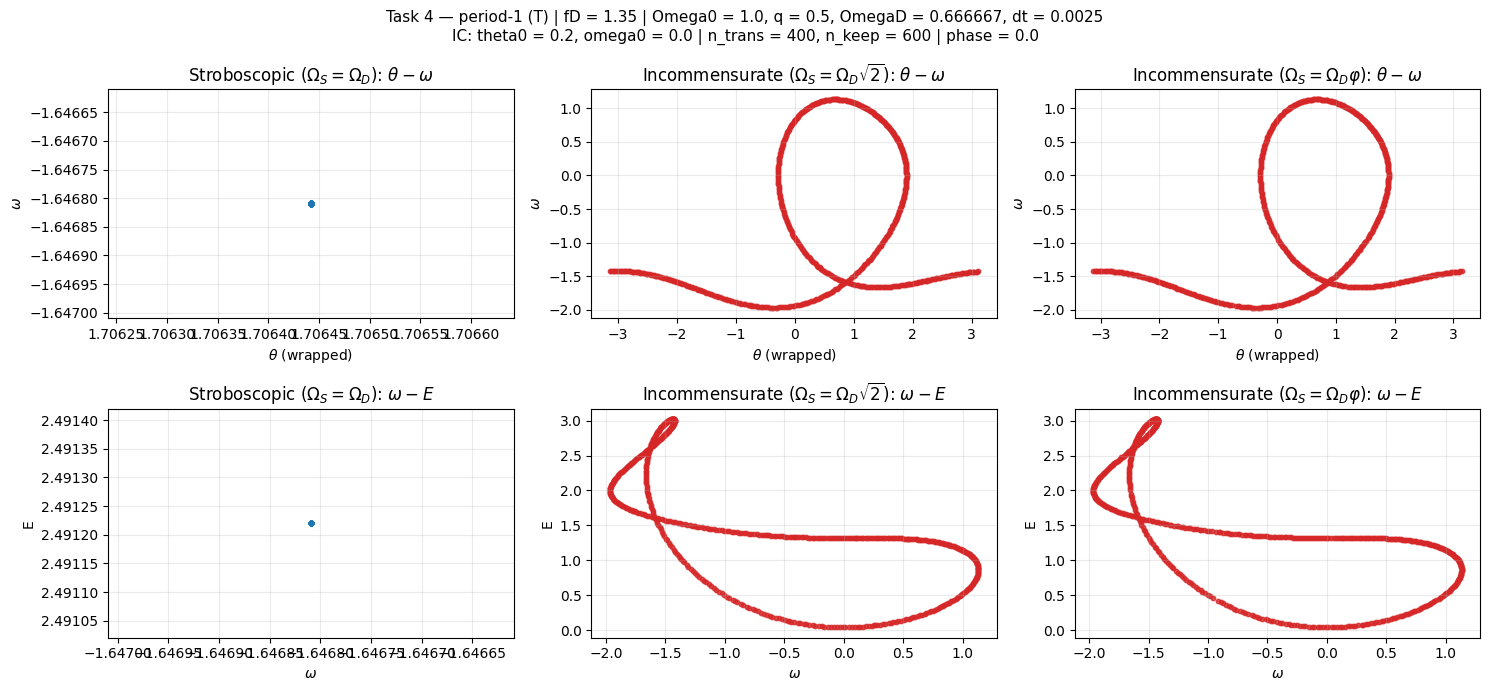

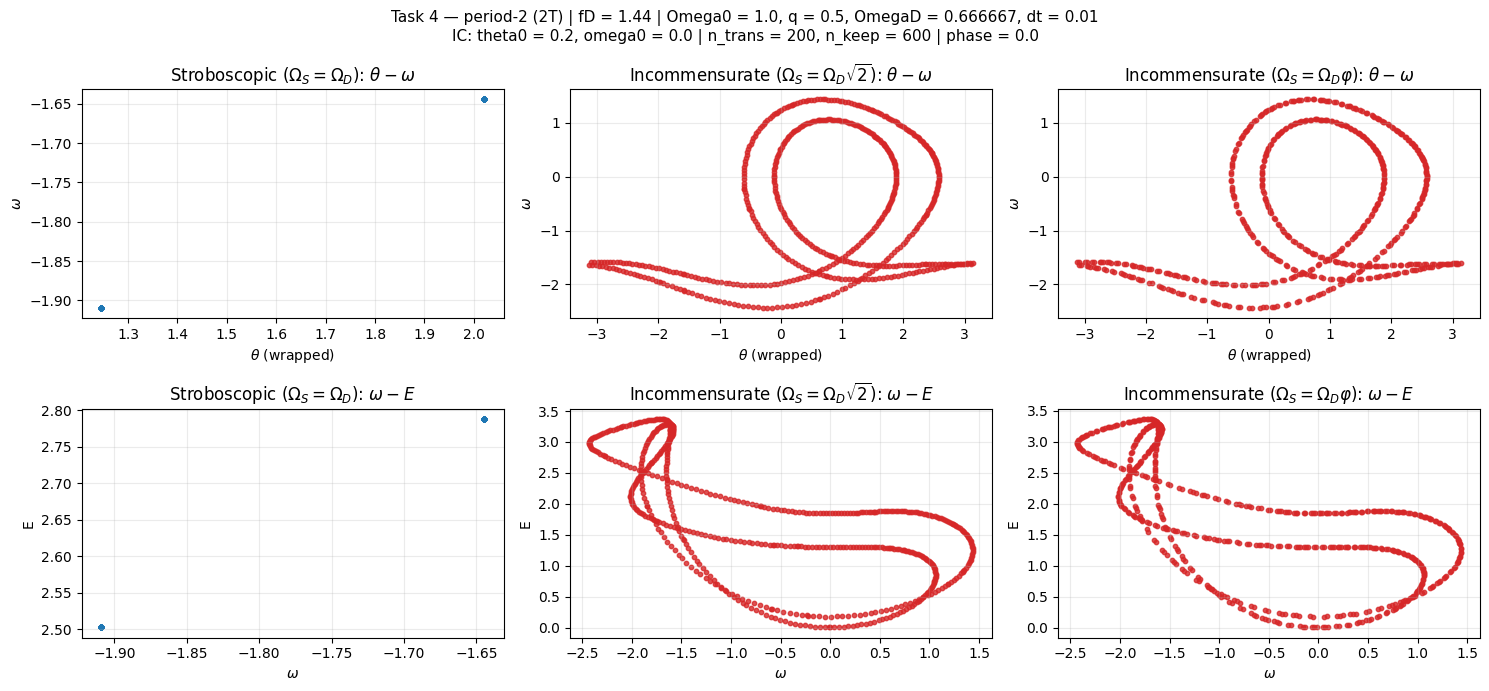

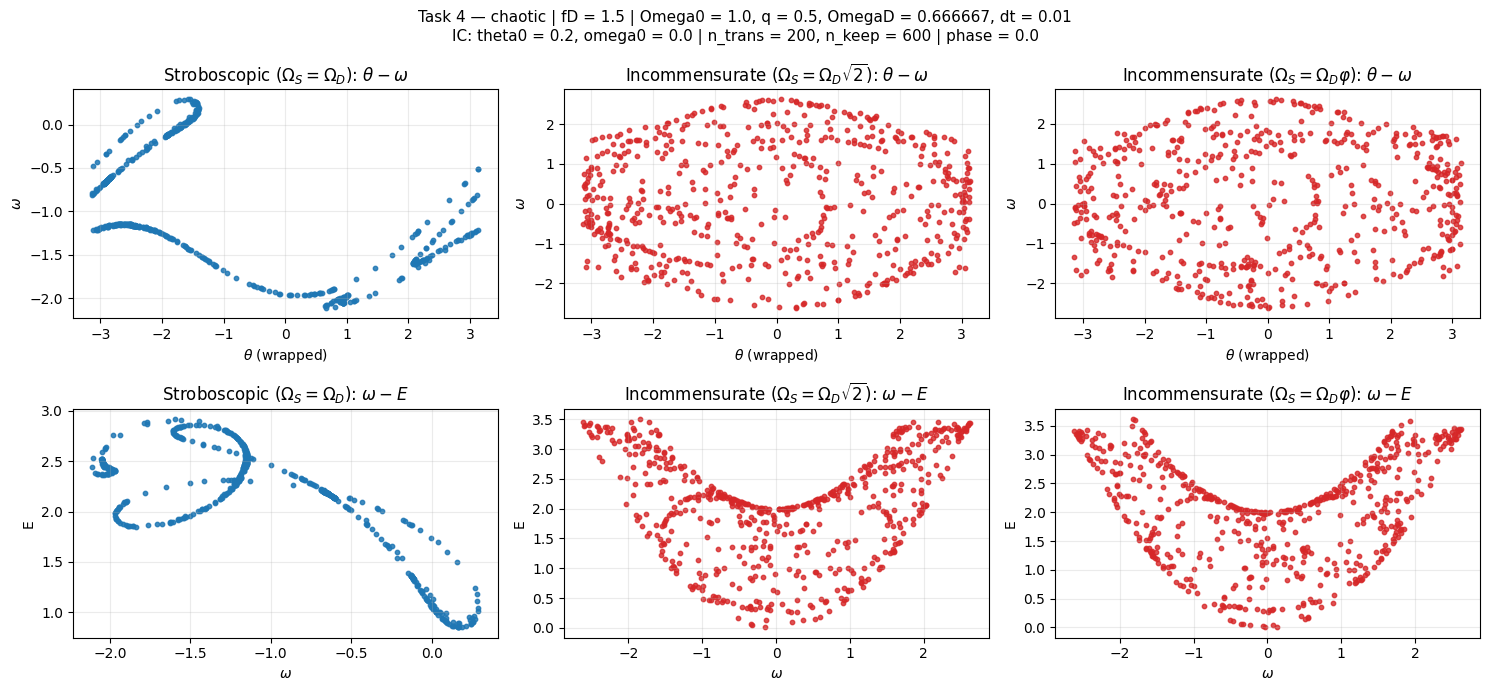

In [ ]:
# Lab 4 — Task 4

import numpy as np;
import matplotlib.pyplot as plt;

PI = np.pi;

def wrap_pm_pi(theta):
    return (theta + PI) % (2.0 * PI) - PI;

# RK2 midpoint: dtheta/dt = omega ; domega/dt = -Omega0^2 sin(theta) - q omega + fD sin(OmegaD t)
def rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax):
    nsteps = int(np.ceil(tmax / dt));
    t = np.linspace(0.0, nsteps * dt, nsteps + 1);

    theta = np.zeros(nsteps + 1, dtype = float);
    omega = np.zeros(nsteps + 1, dtype = float)
    theta[0] = float(theta0);
    omega[0] = float(omega0);
    Omega0sq = Omega0 * Omega0;

    for i in range(nsteps):
        ti = t[i];
        th = theta[i];
        om = omega[i];
        domega1 = -Omega0sq * np.sin(th) - q * om + fD * np.sin(OmegaD * ti);

        th_mid = th + 0.5 * dt * om;
        om_mid = om + 0.5 * dt * domega1;
        t_mid = ti + 0.5 * dt;
        domega2 = -Omega0sq * np.sin(th_mid) - q * om_mid + fD * np.sin(OmegaD * t_mid);

        omega[i + 1] = om + dt * domega2;
        theta[i + 1] = th + dt * om_mid;

    E = 0.5 * omega**2 + Omega0sq * (1.0 - np.cos(theta));
    return t, theta, omega, E;

# Poincaré sampling at sectioning frequency OmegaS - using linear interpolation between integration steps.
def poincare_samples_freq(t, theta, omega, E, OmegaS, n_trans, n_keep, phase = 0.0):
    phase = phase % (2.0 * PI);
    n = np.arange(n_trans, n_trans + n_keep, dtype = int);
    tP = (2.0 * PI * n + phase) / OmegaS;

    # Drop any samples that exceed teh simulation horizon
    check = (tP >= t[0]) & (tP <= t[-1]);
    tP = tP[check];

    thP = np.interp(tP, t, theta);
    omP = np.interp(tP, t, omega);
    EP  = np.interp(tP, t, E);

    return wrap_pm_pi(thP), omP, EP;

def tidy_axes(ax):
    ax.grid(True, alpha = 0.25);
    # Make line to a "dot"
    ax.ticklabel_format(style = 'plain', useOffset = False);

def zoom_like_point(ax, x, y, min_halfspan = 2e-4, nsig = 6.0):
    # Tightly zoom to render line to point ya bozo
    x0 = np.mean(x); y0 = np.mean(y);
    sx = np.std(x);  sy = np.std(y);
    hx = max(min_halfspan, nsig * sx);
    hy = max(min_halfspan, nsig * sy);
    ax.set_xlim(x0 - hx, x0 + hx);
    ax.set_ylim(y0 - hy, y0 + hy);

def plot_and_compare(regime_label, fD, Omega0, q, OmegaD, theta0, omega0, dt, n_trans, n_keep, phase, OmegaS_list, OmegaS_labels,
                      auto_zoom_stroboscopic = False):
    # Ensure we simulate long enough for the *slowest* sampling clock
    n_last = n_trans + n_keep + 5;
    t_need = [];
    for OmegaS in ([OmegaD] + OmegaS_list):
        t_need.append((2.0 * PI * n_last + phase) / OmegaS);
    tmax = max(t_need) + 10.0 * dt;

    t, theta, omega, E = rk2_pendulum(theta0, omega0, Omega0, q, fD, OmegaD, dt, tmax);

    # Build 2x3: (theta-omega) row, (omega-E) row
    fig, ax = plt.subplots(2, 3, figsize = (15, 7))
    fig.suptitle(f"Task 4 — {regime_label} | fD = {fD} | Omega0 = {Omega0}, q = {q}, OmegaD = {OmegaD:.6g}, dt = {dt}\n"
        f"IC: theta0 = {theta0}, omega0 = {omega0} | n_trans = {n_trans}, n_keep = {n_keep} | phase = {phase}", fontsize = 11);

    # Column 1: stroboscopic (OmegaS = OmegaD)
    thD, omD, ED = poincare_samples_freq(t, theta, omega, E, OmegaD, n_trans, n_keep, phase)
    ax[0, 0].scatter(thD, omD, s = 10, color = "tab:blue", alpha = 0.85);
    ax[0, 0].set_title(r"Stroboscopic ($\Omega_S=\Omega_D$): $\theta-\omega$");
    ax[0, 0].set_xlabel(r"$\theta$ (wrapped)");
    ax[0, 0].set_ylabel(r"$\omega$");
    ax[1, 0].scatter(omD, ED, s = 10, color = "tab:blue", alpha = 0.85);
    ax[1, 0].set_title(r"Stroboscopic ($\Omega_S=\Omega_D$): $\omega-E$");
    ax[1, 0].set_xlabel(r"$\omega$");
    ax[1, 0].set_ylabel("E");

    if auto_zoom_stroboscopic:
        zoom_like_point(ax[0, 0], thD, omD);
        zoom_like_point(ax[1, 0], omD, ED);

    # Columns 2 and 3: incommensurates
    for j, (OmegaS, lab) in enumerate(zip(OmegaS_list, OmegaS_labels), start = 1):
        thS, omS, ES = poincare_samples_freq(t, theta, omega, E, OmegaS, n_trans, n_keep, phase);

        ax[0, j].scatter(thS, omS, s = 10, color = "tab:red", alpha = 0.80);
        ax[0, j].set_title(rf"Incommensurate ($\Omega_S={lab}$): $\theta-\omega$");
        ax[0, j].set_xlabel(r"$\theta$ (wrapped)");
        ax[0, j].set_ylabel(r"$\omega$");
        ax[1, j].scatter(omS, ES, s = 10, color = "tab:red", alpha = 0.80);
        ax[1, j].set_title(rf"Incommensurate ($\Omega_S={lab}$): $\omega-E$");
        ax[1, j].set_xlabel(r"$\omega$");
        ax[1, j].set_ylabel("E");

    for a in ax.ravel():
        tidy_axes(a);

    plt.tight_layout();
    plt.show();

def main():
    # Base parameters
    Omega0 = 1.0;
    q = 0.5;
    OmegaD = 2.0 / 3.0;
    phase = 0.0;
    theta0 = 0.2;
    omega0 = 0.0;
    # Transients
    n_keep = 600;
    n_trans_p1 = 400;
    n_trans_p2 = 200;
    n_trans_ch = 200;
    # dts
    dt_p1 = 0.0025;
    dt_p2 = 0.01;
    dt_ch = 0.01;

    # Incommensurate sectioning frequencies (irrational ratio to OmegaD)
    phi = (1.0 + np.sqrt(5.0)) / 2.0;
    OmegaS_list = [OmegaD * np.sqrt(2.0), OmegaD * phi];
    OmegaS_labels = [r"\Omega_D\sqrt{2}", r"\Omega_D\varphi"];

    # Period-1 run
    plot_and_compare("period-1 (T)", fD = 1.35, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = dt_p1,
                      n_trans = n_trans_p1, n_keep = n_keep, phase = phase, OmegaS_list = OmegaS_list, OmegaS_labels = OmegaS_labels,
                      auto_zoom_stroboscopic = True);
    # Period-2 run
    plot_and_compare("period-2 (2T)", fD = 1.44, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = dt_p2,
                      n_trans = n_trans_p2, n_keep = n_keep, phase = phase, OmegaS_list = OmegaS_list, OmegaS_labels = OmegaS_labels,
                      auto_zoom_stroboscopic = False);
    # Chaotic run
    plot_and_compare("chaotic", fD = 1.50, Omega0 = Omega0, q = q, OmegaD = OmegaD, theta0 = theta0, omega0 = omega0, dt = dt_ch,
                      n_trans = n_trans_ch, n_keep = n_keep, phase = phase, OmegaS_list = OmegaS_list, OmegaS_labels = OmegaS_labels,
                      auto_zoom_stroboscopic = False);

if __name__ == "__main__":
    main();
